In [78]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
from pathlib import Path

In [79]:
data_dir = Path('/home/rithik/coding/deep_learning/data/PetImages')
cats_dir = data_dir / 'Cat'
dogs_dir = data_dir / 'Dog'
print(f"Cats directory exists: {cats_dir.exists()}")
print(f"Dogs directory exists: {dogs_dir.exists()}")

Cats directory exists: True
Dogs directory exists: True


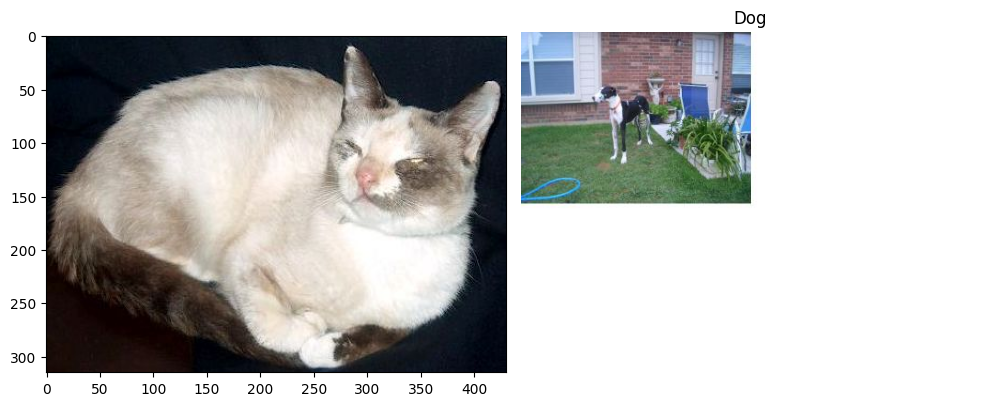

In [80]:
cats_img = list(cats_dir.glob('*'))
dogs_img = list(dogs_dir.glob('*'))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
img_1 = plt.imread(cats_img[500])
img_2 = plt.imread(dogs_img[500])
axes[0].imshow(img_1)
axes[1].imshow(img_2)
axes[1].set_title('Dog')
axes[1].axis('off')
plt.tight_layout()

In [81]:
import cv2
#normalization
cat_sam = []
dog_sam = []
var = 0
img_size = 128
for p in cats_img:
    if var == 1000:
        break
    var += 1

    img = plt.imread(p)
    if img.shape[2] != 3:
        continue
    try:
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32')/255.0
        cat_sam.append(img)
    except Exception as e:
        print(f"Error loading {p}: {e}")
        continue

var = 0
for p in dogs_img:
    if var == 1000:
        break
    var += 1

    img = plt.imread(p)
    if img.shape[2] != 3:
        continue
    try:
        img = cv2.resize(img, (img_size, img_size))
        img = img.astype('float32')/255.0
        dog_sam.append(img)
    except Exception as e:
        print(f"Error loading {p}: {e}")
        continue

In [82]:
len(cat_sam)
len(dog_sam)

997

In [83]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [84]:

model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(128, 128, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))

model.add(layers.GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,729 (413.00 KB)

 Trainable params: 105,729 (413.00 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
X = np.vstack([np.array(cat_sam), np.array(dog_sam)])
y = np.hstack([np.zeros(len(cat_sam)), np.ones(len(dog_sam))])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} images")
print(f"Testing set: {len(X_test)} images")


history = model.fit(
    X_train, y_train,
    epochs=100,  
    batch_size=32,  
    validation_split=0.2,  
    verbose=1 
)


Training set: 1595 images
Testing set: 399 images
Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.5329 - loss: 0.6914 - val_accuracy: 0.5423 - val_loss: 0.6827
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5149 - loss: 0.6926 - val_accuracy: 0.4577 - val_loss: 0.6955
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5345 - loss: 0.6878 - val_accuracy: 0.6332 - val_loss: 0.6675
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5635 - loss: 0.6771 - val_accuracy: 0.6050 - val_loss: 0.6348
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5831 - loss: 0.6608 - val_accuracy: 0.6082 - val_loss: 0.6231
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6003 - loss: 0.6591 - val_accuracy: 0.6238 - val_loss: 0.6168
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6285 - loss: 0.6365 - val_accuracy: 0.6082 - val_loss: 0.6204
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step -

In [86]:
dog_sam[910].shape

(128, 128, 3)

In [87]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Loss: 1.2343
Test Accuracy: 0.7143
Test Accuracy: 71.43%


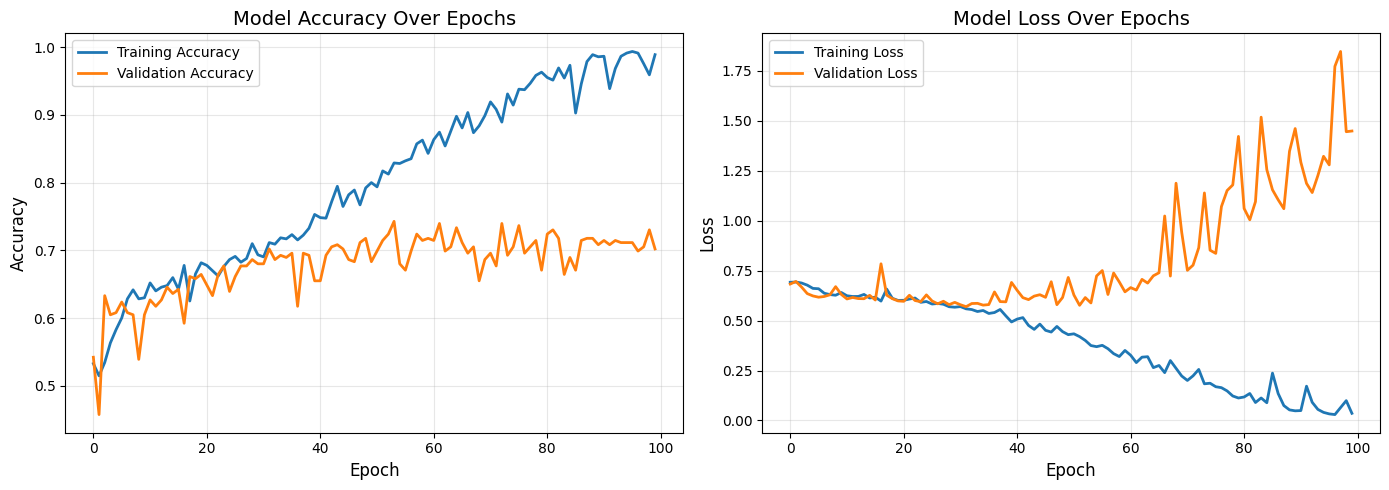

✓ Training visualization complete!


In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss Over Epochs', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training visualization complete!")